In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
df_lyrics = pd.read_csv('lyrics_en_es.csv')
print(df_lyrics.shape)

(6813, 5)


#### Clean 

In [3]:
import re
def clean_lyrics_sentiment(text):
    text = str(text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\(.*?\)', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df_lyrics['lyrics_sentiment'] = df_lyrics['lyrics'].apply(clean_lyrics_sentiment)

In [4]:
df_lyrics.head()

,id,Title,Artists_All,language,lyrics,lyrics_sentiment
0,5aAx2yezTd8zXrkmtKl66Z,Starboy,"The Weeknd, Daft Punk",en,"Ayy\n\nI'm tryna put you in the worst mood, ah...","Ayy I'm tryna put you in the worst mood, ah P1..."
1,7BKLCZ1jbUBVqRi2FVlTVw,Closer,"The Chainsmokers, Halsey",en,"Hey, I was doing just fine before I met you\nI...","Hey, I was doing just fine before I met you I ..."
2,4pdPtRcBmOSQDlJ3Fk945m,Let Me Love You,"DJ Snake, Justin Bieber",en,I used to believe\nWe were burnin' on the edge...,I used to believe We were burnin' on the edge ...
3,5MFzQMkrl1FOOng9tq6R9r,Don't Wan Know,"Maroon 5, Kendrick Lamar",en,"Get on my nerves, get in my room\nFirst, she g...","Get on my nerves, get in my room First, she go..."
4,343YBumqHu19cGoGARUTsd,Fake Love,Drake,en,"Yeah, yeah\n\nI've been down so long, it look ...","Yeah, yeah I've been down so long, it look lik..."


#### Use English songs only

#### Due to compatibility limitations in the sentiment analysis tools, we restricted our dataset to English-language songs to ensure consistent and reliable results.

In [12]:
df_en = df_lyrics[df_lyrics['language'] == 'en'].reset_index(drop=True)
print(f"English songs: {len(df_en)}")

English songs: 5613


### Vadar

In [13]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [14]:
def sentiment_vader(text):
    return SentimentIntensityAnalyzer().polarity_scores(str(text))['compound']

In [16]:
df_en['sentiment_score'] = df_en['lyrics_sentiment'].apply(sentiment_vader)
df_en['sentiment_label'] = pd.cut(df_en['sentiment_score'], bins=3, labels=['negative', 'neutral', 'positive'])

In [17]:
print(df_en.head())

                       id            Title               Artists_All language  \
0  5aAx2yezTd8zXrkmtKl66Z          Starboy     The Weeknd, Daft Punk       en   
1  7BKLCZ1jbUBVqRi2FVlTVw           Closer  The Chainsmokers, Halsey       en   
2  4pdPtRcBmOSQDlJ3Fk945m  Let Me Love You   DJ Snake, Justin Bieber       en   
3  5MFzQMkrl1FOOng9tq6R9r   Don't Wan Know  Maroon 5, Kendrick Lamar       en   
4  343YBumqHu19cGoGARUTsd        Fake Love                     Drake       en   

                                              lyrics  \
0  Ayy\n\nI'm tryna put you in the worst mood, ah...   
1  Hey, I was doing just fine before I met you\nI...   
2  I used to believe\nWe were burnin' on the edge...   
3  Get on my nerves, get in my room\nFirst, she g...   
4  Yeah, yeah\n\nI've been down so long, it look ...   

                                    lyrics_sentiment  sentiment_score  \
0  Ayy I'm tryna put you in the worst mood, ah P1...          -0.9883   
1  Hey, I was doing just fine 

#### Merge with Main Dataset (to get the stage information)

In [18]:
df_main = pd.read_csv('df_pca.csv')
print(df_main.columns.tolist())

['Week_End', 'Week_Start_Fri', 'Week_Label', 'Weekly_Rank', 'id', 'Title', 'Artists_All', 'Weekly_Points', 'Streams', 'Days_Charted', 'Peak_Rank', 'Stage', 'Year', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Song_URL', 'PC1', 'PC2', 'PC3', 'PC4']


In [19]:
df_en_merged = df_main.merge(df_en[['id', 'sentiment_score', 'sentiment_label']], on='id', how='inner')
en_unique = df_en_merged.drop_duplicates(subset='id')
print(f"English merged: {df_en_merged.shape}")

English merged: (66227, 27)


#### Sentiment by Stage

In [20]:
stage_order = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
en_summary = df_en_merged.groupby('Stage')[['sentiment_score']].mean().reindex(stage_order).round(4)

In [21]:
print(en_summary)

                     sentiment_score
Stage                               
Stage 1 (2017-2019)           0.2484
Stage 2 (2020-2022)           0.2698
Stage 3 (2023-2025)           0.2788


#### Plot: English Lyrics Sentiment by Stage

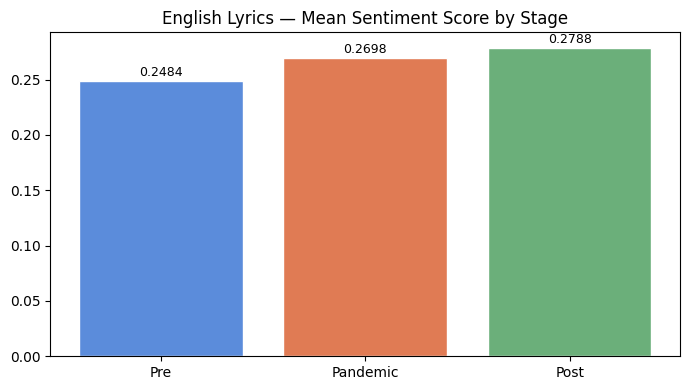

In [22]:
stage_labels = ['Pre', 'Pandemic', 'Post']
colors = ['#5B8CDB', '#E07B54', '#6BAF7A']

fig, ax = plt.subplots(figsize=(7, 4))
vals = en_summary['sentiment_score'].values
bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_title('English Lyrics — Mean Sentiment Score by Stage')
plt.tight_layout()
plt.show()

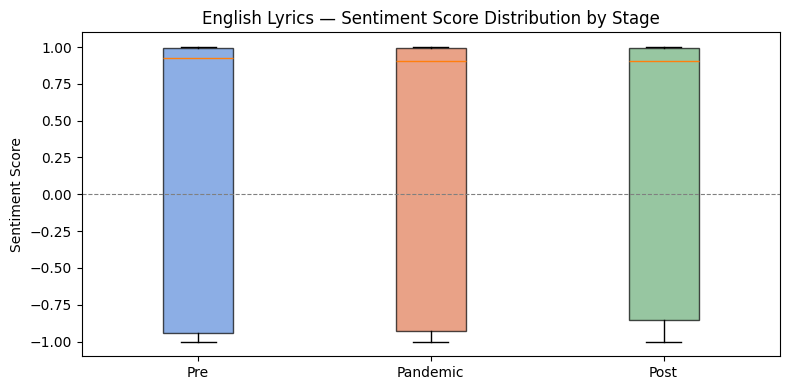

In [23]:
pre_pol = df_en_merged[df_en_merged['Stage']=='Stage 1 (2017-2019)']['sentiment_score'].dropna().values
pan_pol = df_en_merged[df_en_merged['Stage']=='Stage 2 (2020-2022)']['sentiment_score'].dropna().values
pos_pol = df_en_merged[df_en_merged['Stage']=='Stage 3 (2023-2025)']['sentiment_score'].dropna().values

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([pre_pol, pan_pol, pos_pol], tick_labels=stage_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Sentiment Score')
ax.set_title('English Lyrics — Sentiment Score Distribution by Stage')
plt.tight_layout()
plt.show()

### TextBlob

In [25]:
from textblob import TextBlob

In [26]:
def sentiment_textblob(text):
    return TextBlob(str(text)).sentiment.polarity

In [28]:
df_en['polarity_textblob'] = df_en['lyrics_sentiment'].apply(sentiment_textblob)
df_en['polarity_vader'] = df_en['lyrics_sentiment'].apply(sentiment_vader)

In [29]:
print(df_en[['Title', 'polarity_textblob', 'polarity_vader']].head())

             Title  polarity_textblob  polarity_vader
0          Starboy           0.131546         -0.9883
1           Closer           0.184014          0.9880
2  Let Me Love You           0.355556          0.9794
3   Don't Wan Know           0.142143         -0.9874
4        Fake Love           0.032703          0.9916


#### Sentiment by Stage¶

In [30]:
df_en_merged = df_main.merge(
    df_en[['id', 'polarity_textblob', 'polarity_vader']], on='id', how='inner')
en_unique = df_en_merged.drop_duplicates(subset='id')

In [38]:
stage_order = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
en_summary2 = df_en_merged2.groupby('Stage')[['polarity', 'subjectivity']].mean().reindex(stage_order).round(4)
print(en_summary2)

                     polarity  subjectivity
Stage                                      
Stage 1 (2017-2019)    0.0675        0.5116
Stage 2 (2020-2022)    0.0778        0.5180
Stage 3 (2023-2025)    0.0972        0.5046


#### Plot: English Lyrics Sentiment by Stage¶

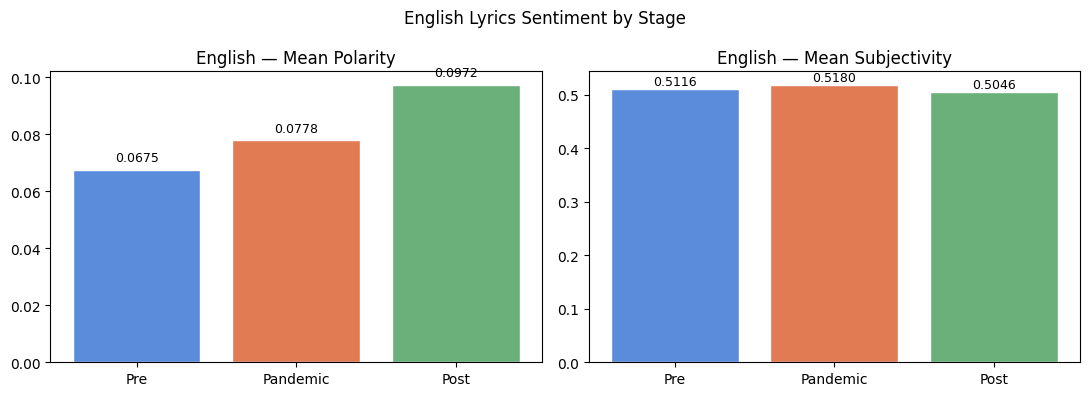

In [36]:
stage_labels = ['Pre', 'Pandemic', 'Post']
colors = ['#5B8CDB', '#E07B54', '#6BAF7A']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['polarity', 'subjectivity'], ['Mean Polarity', 'Mean Subjectivity']):
    vals = en_summary2[col].values
    bars = ax.bar(stage_labels, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'English — {title}')
plt.suptitle('English Lyrics Sentiment by Stage')
plt.tight_layout()
plt.show()

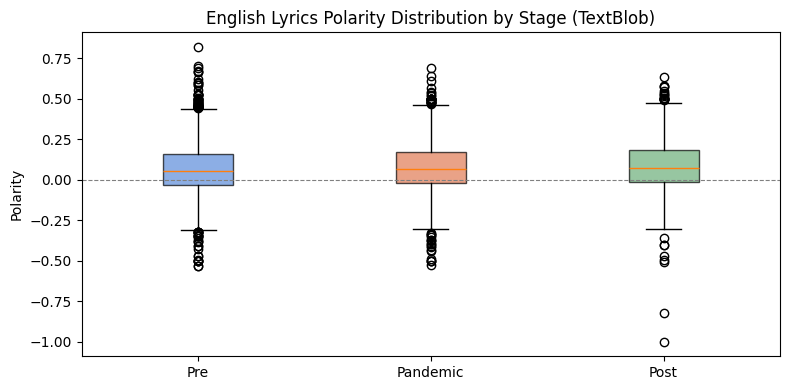

In [39]:
pre_pol = en_unique2[en_unique2['Stage']=='Stage 1 (2017-2019)']['polarity'].dropna().values
pan_pol = en_unique2[en_unique2['Stage']=='Stage 2 (2020-2022)']['polarity'].dropna().values
pos_pol = en_unique2[en_unique2['Stage']=='Stage 3 (2023-2025)']['polarity'].dropna().values

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([pre_pol, pan_pol, pos_pol], tick_labels=stage_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Polarity')
ax.set_title('English Lyrics Polarity Distribution by Stage (TextBlob)')
plt.tight_layout()
plt.show()